# Problem Session 5

The problems in this notebook will cover the content covered in our Inference I lectures including:
- Hypothesis Testing
- Confidence Intervals
- Linear Regression Inference

#### 1. The dangers of early peeking in A/B testing

One especially common use of hypothesis testing in data science is "A/B testing".

Many companies prioritize data informed decision making and have very mature A/B testing platforms to trial changes before adoption.  Here is an example of an A/B test which comes from the book "Trustworthy Online Controlled Experiments" by Kohavi, Tang and Xu:

Someone at your company proposes implementing a coupon code system.  To rapidly get some idea of the potential impacts even *before* implementing the complete system you decide to implement the following A/B test:  for a period of two weeks you will show half of your customers your standard checkout page (the "control group"), and you will show the other half a new checkout page which has a coupon code box (the "treatment group"). Since there are no coupon codes in existence yet, putting anything in the box will simply display "invalid code" and otherwise do nothing.

You will monitor how customers interact with the coupon code box (how many people click on it, enter anything into it, enter one or more attempted codes, etc), how long they stay on the checkout page in the control and treatment group, what fraction of customers who make it to the checkout page who actually complete their purchase, and the revenue per customer who made it to the checkout page.

In this example, the mere presence of a coupon code box significantly reduced revenue per customer with an effect size large enough to scuttle the project!

It is common (but ill advised) for companies to **continuously** monitor such experiments and stop early when a significant result is obtained in either direction.  The reasoning is that we would not want to continue a disastrous experiment for the full planned time (e.g.  hardly anyone checks out after being presented with the coupon code box), and we would likewise not want to miss out on the benefits by **not** implementing a positive experiment as soon as possible.

In this exercise we will see why early stopping is such a bad idea through simulation.

##### a)

Finish the definition of the following function:

In [1]:
import numpy as np
import pandas as pd

def simulate_data(control_mean, treatment_mean, scale, size):
    '''
    Draws from two normal distributions with the same scale and different means

    Args:
        control_mean:  the mean of the control group
        treatment_mean: the mean of the treatment group
        scale: the common standard deviation of both groups
        size: the shape of both outputs
    
    returns:
        The tuple (control_data, treatment_data)        
    '''
    control_data = np.random.normal(loc = control_mean, scale = scale, size = size)
    treatment_data = np.random.normal(loc = treatment_mean, scale = scale, size = size)
    return (control_data, treatment_data)


# Note: for the probabilistic checks below, the probability of both false positive and negatives are so low as to be effectively zero
# It is a fun little puzzle to estimate these probabilities.
assert(simulate_data(3,3,1,(10,2))[0].shape == (10,2)), "control_data does not have the correct shape"
assert(simulate_data(3,3,1,(10,2))[1].shape == (10,2)), "treatment_data does not have the correct shape"
assert(np.abs(simulate_data(0,3,1,(1000))[0].mean()) < 1  ), "control_data does not have the correct mean"
assert(np.abs(simulate_data(0,3,1,(1000))[1].mean() - 3) < 1  ), "treatment_data does not have the correct mean"
assert(np.abs(simulate_data(0,3,1,(1000))[0].std() - 1) < 0.5 ), "control_data does not have the correct standard deviation"
assert(np.abs(simulate_data(0,3,1,(1000))[1].std() - 1) < 0.5 ), "treatment_data does not have the correct standard deviation"

##### b)

Use  [`ttest_ind`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_ind.html) to finish writing the following two functions:

In [2]:
from statsmodels.stats.weightstats import ttest_ind

def no_early_peeking_results(control_data, treatment_data):
    '''
    Returns the p-value of the t-test comparing the two group means.
    '''
    p_value = ttest_ind(control_data,treatment_data)[1]
    return p_value

assert(no_early_peeking_results([1,2,3], [4,5,6]) == 0.021311641128756727)

In [3]:
def early_peeking_results(control_data, treatment_data, alpha):
    '''
    Runs a t-test on each initial segment of the control and treatment data.

    Args:
        alpha: the threshold for significance.
        
    Returns: 
        (p_value, nobs)
        p_value: the p-value of the first significant such test
        nobs: the number of observations in that test
    
    Example:  
        early_peeking_results([1,2,2,2,2,2], [4,5,5,5,5,5], 0.05)
        Should run a t-test on 
            [1,2], [4,5]
            [1,2,2], [4,5,5]
            [1,2,2,2], [4,5,5,5]
            etc
        when a significant p-value is found it will output
        that p-value and the length of the control group for that test.
    '''
    p_value = 1  # Arbitrary
    i = 2  # Start with the first two observations
    while p_value > alpha and len(control_data) >= i:
        nobs = i
        p_value = ttest_ind(control_data[:i],treatment_data[:i])[1]
        i += 1
    return p_value, nobs

assert(early_peeking_results([1,2,2,2,2,2], [4,5,5,5,5,5], 0.05)[0] == 0.0031255892524457277)

# Be careful about off by one errors here!
assert(early_peeking_results([1,2,2,2,2,2], [4,5,5,5,5,5], 0.05)[1] == 3)

##### c)

We will now see the impact of early peeking on the false positive rate.

By setting both the control and training mean to 0, and $\alpha = 0.05$ for the threshold for significance, we should expect to see a false positive rate of roughly $0.05$.  We will see that early peeking wildly inflates the false positive rate!

This is bad news for our company, because we will be mislead into thinking that our treatment has a significant effect (in either direction) when there really is no effect at all.

In [4]:
def comparing_procedures(size = 1000, 
                         num_simulations = 100, 
                        alpha = 0.05):
    '''
    Simulates data from control and treatment groups both with mean 0 and variance 1.
    Returns a tuple of the following variables:
        no_early_peeking_false_positives of type int
            Number of significant trials without early peeking
        early_peeking_false_positives of type int
            Number of "significant" trials with early peeking
        early_peeking_nobs of type list(int)
            List of the number of samples in the "significant" early peeking trials.
    '''            
    no_early_peeking_false_positives = 0 # Initialize counters for false positives without early peeking
    early_peeking_false_positives = 0    # Initialize counters for false positives with early peeking
    early_peeking_nobs = []              # List to store the number of observations at which early peeking falsely signaled significance

    # Repeat the simulation num_simulations times to estimate probabilities
    for i in range(num_simulations):

        # Simulate data for control and treatment groups, both with mean 0 and standard deviation 1
        # This ensures there is actually no real effect (false positives only come from random variation)
        control_data, treatment_data = simulate_data(control_mean=0, treatment_mean=0, scale=1, size=size)
       
        # Run a standard t-test without early peeking and get the p-value
        p = no_early_peeking_results(control_data, treatment_data)
        
        # Run a t-test with early peeking, checking significance after each new observation
        # p_early is the first p-value below alpha, nobs is the number of samples used when significance was detected
        p_early, nobs = early_peeking_results(control_data, treatment_data, alpha)
        
        # If the no-peeking p-value is below alpha, increment the false positive counter
        if p < alpha:
            no_early_peeking_false_positives += 1
        
        # If the early-peeking p-value is below alpha, increment the false positive counter
        # and store the number of observations where it occurred
        if p_early < alpha:
            early_peeking_false_positives +=1
            early_peeking_nobs.append(nobs)
        
    # Return the counts of false positives and the list of sample sizes for early peeking
    return (no_early_peeking_false_positives, early_peeking_false_positives, early_peeking_nobs)

In [5]:
num_simulations = 100
size = 1000
(no_early_peeking_false_positives, early_peeking_false_positives, early_peeking_nobs) = comparing_procedures(num_simulations=num_simulations, size = size)
print(f"The number of false positives with no early peeking is {no_early_peeking_false_positives} out of {num_simulations}")
print(f"The number of false positives with early peeking is {early_peeking_false_positives} out of {num_simulations}")
print(f"The number of observations to reach those false positives (out of {size}) were \n {early_peeking_nobs[early_peeking_nobs != 1000]}")

The number of false positives with no early peeking is 6 out of 100
The number of false positives with early peeking is 60 out of 100
The number of observations to reach those false positives (out of 1000) were 
 368


In [6]:
# Preview
early_peeking_nobs[:10] 

[4, 368, 10, 18, 24, 31, 2, 899, 10, 6]

#### 2. Confidence Intervals and Linear Regression Coefficients


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf

#### a) Problem introduction

The following [dataset](https://dasl.datadescription.com/datafile/bodyfat/) comes from the [Data and Story Library](https://dasl.datadescription.com/). 

Our target variable is `Pct.BF` which stands for "percent body fat".

Age is given in years, weight is given in pounds, and all other measurements are given in inches.

In [8]:
bf = pd.read_csv('../../data/bodyfat.csv')
bf.head()

,Pct.BF,Age,Weight,Height,Neck,Chest,Abdomen,Waist,Hip,Thigh,Knee,Ankle,Bicep,Forearm,Wrist
0,12.3,23,154.25,67.75,36.2,93.1,85.2,33.543307,94.5,59.0,37.3,21.9,32.0,27.4,17.1
1,6.1,22,173.25,72.25,38.5,93.6,83.0,32.677165,98.7,58.7,37.3,23.4,30.5,28.9,18.2
2,25.3,22,154.00,66.25,34.0,95.8,87.9,34.606299,99.2,59.6,38.9,24.0,28.8,25.2,16.6
3,10.4,26,184.75,72.25,37.4,101.8,86.4,34.015748,101.2,60.1,37.3,22.8,32.4,29.4,18.2
4,28.7,24,184.25,71.25,34.4,97.3,100.0,39.370079,101.9,63.2,42.2,24.0,32.2,27.7,17.7


This table does not include [Body Mass Index](https://en.wikipedia.org/wiki/Body_mass_index), but we can calculate it from the data.

Add a new column `BMI` which records this.

In [9]:
bf['BMI'] = bf['Weight']/bf['Height']*703
bf.head()

,Pct.BF,Age,Weight,Height,Neck,Chest,Abdomen,Waist,Hip,Thigh,Knee,Ankle,Bicep,Forearm,Wrist,BMI
0,12.3,23,154.25,67.75,36.2,93.1,85.2,33.543307,94.5,59.0,37.3,21.9,32.0,27.4,17.1,1600.557196
1,6.1,22,173.25,72.25,38.5,93.6,83.0,32.677165,98.7,58.7,37.3,23.4,30.5,28.9,18.2,1685.740484
2,25.3,22,154.00,66.25,34.0,95.8,87.9,34.606299,99.2,59.6,38.9,24.0,28.8,25.2,16.6,1634.143396
3,10.4,26,184.75,72.25,37.4,101.8,86.4,34.015748,101.2,60.1,37.3,22.8,32.4,29.4,18.2,1797.636678
4,28.7,24,184.25,71.25,34.4,97.3,100.0,39.370079,101.9,63.2,42.2,24.0,32.2,27.7,17.7,1817.933333


The name of the target variable `Pct.BF` is a bit problematic for `statsmodels` because of the period.  Change the name of that column to `BFP`.

In [10]:
bf = bf.rename(columns={'Pct.BF':'BFP'})
bf.columns

Index(['BFP', 'Age', 'Weight', 'Height', 'Neck', 'Chest', 'Abdomen', 'Waist',
       'Hip', 'Thigh', 'Knee', 'Ankle', 'Bicep', 'Forearm', 'Wrist', 'BMI'],
      dtype='object')

#### b)  Train/Test Split

One of the reasons that we have a reproducibility crisis in several fields of science is that researchers test multiple hypotheses on their full dataset and only report the statistically significant findings.  As you should know, assuming that the null hypotheses are actually all true you will find one "significant" result for every $20$ things you try.

Even without deliberate "p-hacking" one can still be led astray as the article ["The Garden of Forking Paths"](http://www.stat.columbia.edu/%7Egelman/research/unpublished/p_hacking.pdf) by Gelman and Loken so convincingly argues.  

One way to combat this is by conducting a replication study, but that can be expensive.

Alternatively can conduct your own replication study by splitting your data in half.  Experiment to your hearts content on the training data.  Find whatever interesting potential associations you like without worrying.  Then test one of these hypotheses on your testing set.  The downside is that your study is less powerful since you have access to only half the data.  The upside is that the data used to generate your research hypothesis is not the same data which you use to test your hypothesis (a very good thing).

For these reasons, make a 50/50 train test split of the bodyfat data:

In [11]:
from sklearn.model_selection import train_test_split

bf_train, bf_test = train_test_split(bf,test_size=0.5, random_state=216,shuffle=True)
print(bf_train.head())
print(bf_test.head())

      BFP  Age  Weight  Height  Neck  Chest  Abdomen      Waist    Hip  Thigh  \
218  12.4   54  153.25   70.50  38.5   99.0     91.8  36.141732   96.2   57.7   
141   9.4   23  159.75   72.25  35.5   92.1     77.1  30.354331   93.9   56.1   
49    6.6   40  139.25   69.00  34.3   89.2     77.9  30.669291   91.0   51.4   
186  20.5   41  202.25   72.50  40.8  109.2     98.0  38.582677  101.8   62.8   
138  24.9   40  176.75   71.00  37.4   98.6     93.1  36.653543  101.6   59.1   

     Knee  Ankle  Bicep  Forearm  Wrist          BMI  
218  38.1   23.9   31.4     29.9   18.9  1528.152482  
141  36.1   22.7   30.5     27.2   18.2  1554.384083  
49   34.9   21.0   26.7     26.1   17.2  1418.735507  
186  41.3   24.8   36.6     32.4   18.8  1961.127586  
138  39.6   21.6   30.8     27.9   16.6  1750.073944  
      BFP  Age  Weight  Height  Neck  Chest  Abdomen      Waist    Hip  Thigh  \
142  10.3   23  188.15   77.50  38.0   96.6     85.3  33.582677  102.5   59.1   
225  25.2   55  198.5

#### c) Exploring possible associations

Fit the following regression models using `statsmodels` (not `sklearn`):

Note:  We imported `statsmodels.formula.api` as `smf`.  It is convenient to use formulas for fitting these models.  For example, if you wanted to regress `Neck` on `Chest` and `Height` you could write

```python
neck_model = smf.ols('Neck ~ Chest + Height', data=bf_train).fit()
```

In [12]:
# full_model uses BMI, Waist, and Abdomen as features
full_model = smf.ols('BFP ~ BMI + Waist + Abdomen', data=bf_train).fit()

# waist_model uses Waist as the only feature
waist_model = smf.ols('BFP ~ Waist', data=bf_train).fit()

# bmi_model uses BMI as the only feature
bmi_model = smf.ols('BFP ~ BMI', data=bf_train).fit()

# abdomen_model uses abdomen as the only feature
abdomen_model = smf.ols('BFP ~ Abdomen', data=bf_train).fit()

Look at the summary of each model.  Do they tell a consistent story?

For each model discuss the following with your group:

1. Describe *precisely* what is the meaning of the $p$-value listed for each feature.
2. Describe *precisely* what is the meaning of the $95\%$ confidence interval listed for each feature.
2. How can it be that a feature is considered significant by one model and not by another?
3. Can you explain any unusual findings? 

In [13]:
full_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    BFP   R-squared:                       0.666
Model:                            OLS   Adj. R-squared:                  0.657
Method:                 Least Squares   F-statistic:                     80.35
Date:                Tue, 07 Oct 2025   Prob (F-statistic):           1.16e-28
Time:                        17:45:38   Log-Likelihood:                -360.04
No. Observations:                 125   AIC:                             728.1
Df Residuals:                     121   BIC:                             739.4
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -43.5187      4.095    -10.627      0.000     -51.626     -35.412
BMI           -0.0145      0.004     -3.345      0.001      -0.023      -0.006
Waist       1.076e+06   1.41e+06      0.761      0.448   -1.72e+06    3.87e+06
Abdomen    -4.235e+05   5.56e+05     -0.761      0.448   -1.52e+06    6.78e+05
==============================================================================
Omnibus:                        4.531   Durbin-Watson:                   2.090
Prob(Omnibus):                  0.104   Jarque-Bera (JB):                2.464
Skew:                           0.034   Prob(JB):                        0.292
Kurtosis:                       2.316   Cond. No.                     6.92e+09
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The smallest eigenvalue is 8.33e-12. This might indicate that there are
strong multicollinearity problems or that the design matrix is singular.
"""

In [14]:
waist_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    BFP   R-squared:                       0.632
Model:                            OLS   Adj. R-squared:                  0.629
Method:                 Least Squares   F-statistic:                     211.0
Date:                Tue, 07 Oct 2025   Prob (F-statistic):           1.89e-28
Time:                        17:45:38   Log-Likelihood:                -366.11
No. Observations:                 125   AIC:                             736.2
Df Residuals:                     123   BIC:                             741.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -38.3964      3.959     -9.699      0.000     -46.233     -30.560
Waist          1.5823      0.109     14.524      0.000       1.367       1.798
==============================================================================
Omnibus:                        6.151   Durbin-Watson:                   2.218
Prob(Omnibus):                  0.046   Jarque-Bera (JB):                2.949
Skew:                           0.041   Prob(JB):                        0.229
Kurtosis:                       2.252   Cond. No.                         353.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [15]:
bmi_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    BFP   R-squared:                       0.443
Model:                            OLS   Adj. R-squared:                  0.438
Method:                 Least Squares   F-statistic:                     97.76
Date:                Tue, 07 Oct 2025   Prob (F-statistic):           2.55e-17
Time:                        17:45:38   Log-Likelihood:                -391.98
No. Observations:                 125   AIC:                             788.0
Df Residuals:                     123   BIC:                             793.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -18.1076      3.766     -4.808      0.000     -25.563     -10.653
BMI            0.0209      0.002      9.887      0.000       0.017       0.025
==============================================================================
Omnibus:                        1.151   Durbin-Watson:                   2.271
Prob(Omnibus):                  0.562   Jarque-Bera (JB):                1.127
Skew:                          -0.102   Prob(JB):                        0.569
Kurtosis:                       2.582   Cond. No.                     1.34e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.34e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [16]:
abdomen_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    BFP   R-squared:                       0.632
Model:                            OLS   Adj. R-squared:                  0.629
Method:                 Least Squares   F-statistic:                     211.0
Date:                Tue, 07 Oct 2025   Prob (F-statistic):           1.89e-28
Time:                        17:45:38   Log-Likelihood:                -366.11
No. Observations:                 125   AIC:                             736.2
Df Residuals:                     123   BIC:                             741.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -38.3964      3.959     -9.699      0.000     -46.233     -30.560
Abdomen        0.6230      0.043     14.524      0.000       0.538       0.708
==============================================================================
Omnibus:                        6.151   Durbin-Watson:                   2.218
Prob(Omnibus):                  0.046   Jarque-Bera (JB):                2.949
Skew:                           0.041   Prob(JB):                        0.229
Kurtosis:                       2.252   Cond. No.                         895.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Use an F-test to compare the full model to the waist, abdomen, and bmi models.  What is the precise meaning of the $p$-value of each test? 

In [17]:
# Perform the F-test
f_test_waist = full_model.compare_f_test(waist_model)
f_test_bmi = full_model.compare_f_test(bmi_model)
f_test_abdomen = full_model.compare_f_test(abdomen_model)


print("p-value of full compared to waist model:", f_test_waist[1])
print("p-value of full compared to abdomen model:", f_test_abdomen[1])
print("p-value of full compared to BMI model:", f_test_bmi[1])


p-value of full compared to waist model: 0.0028011624081173457
p-value of full compared to abdomen model: 0.0028011593333272947
p-value of full compared to BMI model: 3.729263347988355e-14


If you have not already, make a plot of `waist` against `abdomen` to help explain what we have been seeing:

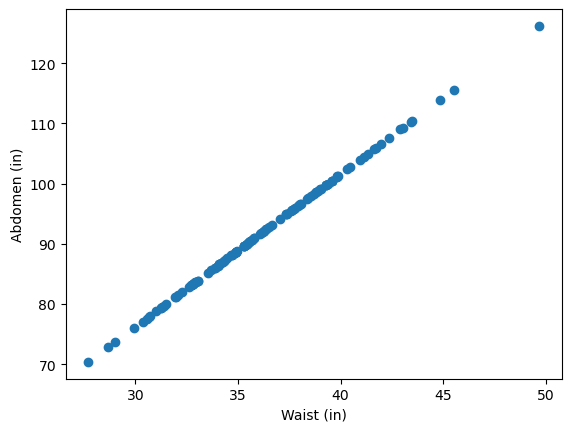

In [18]:
plt.scatter(bf_train.Waist,bf_train.Abdomen)
plt.xlabel('Waist (in)')
plt.ylabel('Abdomen (in)')
plt.show()

In [19]:
print(bf.Waist.min())
print(bf.Waist.max())

27.322835
49.685039


#### d)  Final model evaluation on testing set.

Let's choose the waist model as our final model.  Fit the model to the testing data and look at the summary.  Discuss with your group.

In [20]:
final_model = smf.ols('BFP ~ Waist', data=bf_test).fit()

final_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    BFP   R-squared:                       0.715
Model:                            OLS   Adj. R-squared:                  0.712
Method:                 Least Squares   F-statistic:                     307.9
Date:                Tue, 07 Oct 2025   Prob (F-statistic):           2.78e-35
Time:                        17:45:38   Log-Likelihood:                -373.89
No. Observations:                 125   AIC:                             751.8
Df Residuals:                     123   BIC:                             757.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -46.2234      3.758    -12.302      0.000     -53.661     -38.786
Waist          1.7932      0.102     17.546      0.000       1.591       1.995
==============================================================================
Omnibus:                        1.328   Durbin-Watson:                   2.098
Prob(Omnibus):                  0.515   Jarque-Bera (JB):                1.304
Skew:                           0.143   Prob(JB):                        0.521
Kurtosis:                       2.590   Cond. No.                         318.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

#### e) Confidence and prediction intervals

Make a graph which includes:

1. A scatterplot of the data
2. The confidence interval for the predicted mean response.
3. The prediction interval for the response.

Note:  You will want to use the [`.get_predictions`](https://www.statsmodels.org/dev/generated/statsmodels.regression.linear_model.OLSResults.get_prediction.html) method of an ols model which returns prediction results. These prediction results then have a [`.summary_frame`](https://www.statsmodels.org/dev/generated/statsmodels.regression.linear_model.PredictionResults.summary_frame.html) method (the documentation is non-existent and you will need to look at the source to see what this does) which contain the confidence and prediction interval bounds you want.

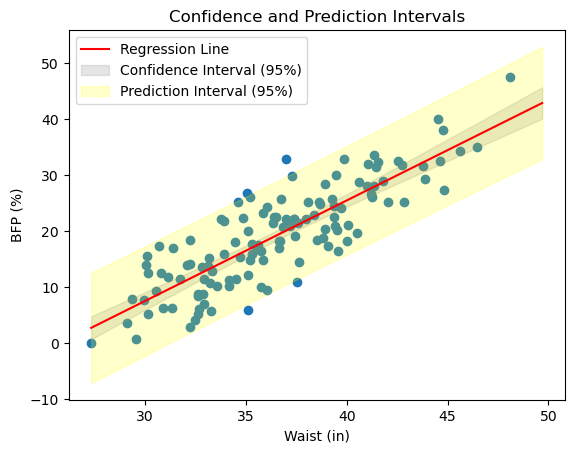

In [21]:
xs = np.linspace(bf.Waist.min(), bf.Waist.max())

# Create a DataFrame with the same structure as the one used for training
df_xs = pd.DataFrame({'Waist': xs})

# Get predictions using the new DataFrame
predictions = final_model.get_prediction(df_xs)

pred_summary_frame = predictions.summary_frame(alpha=0.05)

# Extract values
mean_pred = pred_summary_frame['mean']
mean_ci_lower = pred_summary_frame['mean_ci_lower']
mean_ci_upper = pred_summary_frame['mean_ci_upper']
obs_ci_lower = pred_summary_frame['obs_ci_lower']
obs_ci_upper = pred_summary_frame['obs_ci_upper']

# Plotting
plt.scatter(bf_test.Waist,bf_test.BFP)
plt.plot(xs, mean_pred, 'r-', label='Regression Line')
plt.fill_between(xs, mean_ci_lower, mean_ci_upper, color='gray', alpha=0.2, label='Confidence Interval (95%)')
plt.fill_between(xs, obs_ci_lower, obs_ci_upper, color='yellow', alpha=0.2, label='Prediction Interval (95%)')
# plt.xlabel('X')
# plt.ylabel('y')
plt.xlabel('Waist (in)')
plt.ylabel('BFP (%)')
plt.legend()
plt.title('Confidence and Prediction Intervals')
plt.show()


Find the confidence and prediction interval for Body Fat Percentage at a waist size of 45 inches.  Explain these in a way that a layman could understand what they mean.

In [22]:
bfp45in = final_model.get_prediction(pd.DataFrame({'Waist': [45]})).summary_frame(alpha=0.05)
# dir(bfp45in)

In [23]:
print("mean:",bfp45in['mean'][0])          # Predicted mean BFP
print("mean_ci_lower:",bfp45in['mean_ci_lower'][0])
print("mean_ci_upper:",bfp45in['mean_ci_upper'][0])
print("obs_ci_lower:",bfp45in['obs_ci_lower'][0])
print("obs_ci_upper:",bfp45in['obs_ci_upper'][0])


mean: 34.468765863301826
mean_ci_lower: 32.55022885284252
mean_ci_upper: 36.38730287376113
obs_ci_lower: 24.666646740891522
obs_ci_upper: 44.27088498571213
